# In Class 5/14
## Keras and Tensorflow
### Dirks Wright

### Setting up venv

The following code cells are only necessary if you want a new venv or one has not been set up before

In [ ]:
### set up new environment
import venv
venv.create('.venv', with_pip=True)

In [ ]:
### switch to the virtual environment
import subprocess
import sys
from pathlib import Path

venv_python = Path(".venv/Scripts/python.exe")

subprocess.check_call([venv_python, "-m", "pip", "install", "tensorflow", "ipykernel"])

In [ ]:
### register new kernel
subprocess.check_call([
    venv_python, "-m", "ipykernel", "install",
    "--user",
    "--name=tf-env",
    "--display-name=Python (tf-env)"
])

#### Install the required packages

packages are not installed in a new venv

In [1]:
### install tensor flow
!pip install tensorflow


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
### install required packages
!pip install pandas numpy scikit-learn


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
### import required packages

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

In [5]:
! pip install palmerpenguins
from palmerpenguins import load_penguins
penguins = load_penguins()
penguins.head()


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [6]:
### drop nan rows
penguins = penguins.dropna()
penguins.shape

(333, 8)

In [7]:
# defining X
penguins_x = pd.concat([penguins[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']], pd.get_dummies(penguins['sex'])], axis = 1)
# penguins_x = penguins_x[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'female', 'male']]
penguins_x

# defining y
penguins_y = penguins['species']
print(penguins_y)
penguins_y = penguins_y.astype('category').cat.codes.to_numpy()
penguins_y

# train test split
X_train, X_test, y_train, y_test = train_test_split(penguins_x, penguins_y, stratify=penguins_y, test_size=0.2, random_state=42)

y_train

0         Adelie
1         Adelie
2         Adelie
4         Adelie
5         Adelie
         ...    
339    Chinstrap
340    Chinstrap
341    Chinstrap
342    Chinstrap
343    Chinstrap
Name: species, Length: 333, dtype: str


array([2, 1, 2, 0, 0, 2, 2, 0, 0, 2, 0, 2, 1, 1, 0, 1, 2, 0, 2, 1, 0, 0,
       0, 2, 0, 2, 2, 1, 2, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 2, 2, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2,
       1, 1, 1, 0, 2, 2, 0, 0, 2, 0, 2, 2, 2, 0, 1, 1, 2, 0, 2, 1, 2, 0,
       2, 0, 2, 0, 1, 2, 1, 0, 0, 0, 1, 1, 1, 2, 2, 0, 0, 2, 2, 1, 2, 1,
       2, 0, 2, 2, 0, 0, 2, 0, 2, 0, 0, 1, 1, 1, 2, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 2, 0, 0, 2, 0, 2, 2, 0, 2, 1, 1, 2, 0, 2, 2, 2, 2, 0, 0,
       2, 0, 0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 2, 2, 2, 1,
       1, 0, 2, 0, 2, 2, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 2, 0, 0, 1, 0, 0,
       1, 1, 0, 2, 0, 1, 0, 2, 0, 1, 2, 2, 2, 1, 1, 1, 2, 1, 0, 2, 0, 0,
       2, 2, 0, 2, 0, 0, 2, 0, 0, 1, 0, 1, 2, 1, 2, 2, 0, 2, 2, 2, 0, 2,
       2, 2, 0, 0, 0, 2, 1, 0, 0, 0, 0, 2, 1, 2, 2, 0, 0, 2, 0, 0, 1, 0,
       2, 0], dtype=int8)

In [8]:
# Scaling the data

scalar = StandardScaler()

# fit the scaler on the training data and transform both training and test data
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

X_train_scaled

array([[ 1.08239437,  0.16732502, -1.99231135,  0.83478089,  1.0461779 ,
        -1.0461779 ],
       [-0.21564233,  1.22705014,  1.25552054,  0.1212471 , -0.95586038,
         0.95586038],
       [ 2.19499725,  0.87989881, -0.52063753,  1.4769613 , -0.95586038,
         0.95586038],
       ...,
       [ 0.21703657,  0.02115604,  1.25552054, -0.37822656, -0.95586038,
         0.95586038],
       [ 1.453262  ,  0.80681432, -0.46989015,  1.33425454, -0.95586038,
         0.95586038],
       [-0.77194377, -1.91558298,  0.90028893, -0.80634683,  1.0461779 ,
        -1.0461779 ]], shape=(266, 6))

## Defining the Model

In [8]:
#construct the model
tf.random.set_seed(222)

inputs = keras.Input(shape=(6,))
x = layers.Dense(7, activation = 'relu')(inputs)
x = layers.Dense(5, activation = 'relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model")

In [9]:
model.summary()

Model: "penguin_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │            49 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107 (428.00 B)

 Trainable params: 107 (428.00 B)

 Non-trainable params: 0 (0.00 B)

### Model training parameters (compile) & model training (fit)

In [10]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history = model.fit(X_train_scaled, y_train,
                    batch_size = 128,
                    epochs=10,
                    validation_split=0.2,
                    verbose=1)

scores = model.evaluate(X_test_scaled, y_test, verbose = 1)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 350ms/step - accuracy: 0.3632 - loss: 1.1266 - val_accuracy: 0.3889 - val_loss: 1.0951
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.3679 - loss: 1.1174 - val_accuracy: 0.3889 - val_loss: 1.0864
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.3774 - loss: 1.1083 - val_accuracy: 0.4074 - val_loss: 1.0778
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.3821 - loss: 1.0994 - val_accuracy: 0.4074 - val_loss: 1.0697
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.3868 - loss: 1.0907 - val_accuracy: 0.4074 - val_loss: 1.0618
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.3962 - loss: 1.0824 - val_accuracy: 0.4074 - val_loss: 1.0542
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.4009 - loss: 1.0741 - val_accuracy: 0.3889 - val_loss: 1.0467
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.4104 - loss: 1.0660 - val_accuracy: 0.4074 - val_loss: 1.039

### Evaluation on the test data

In [11]:
# evaluate the model using the test set
y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print("\n Test Set Evaluation:")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step

 Test Set Evaluation:
Test Accuracy: 0.4627
Test Precision: 0.3547
Test Recall: 0.4627
Test F1 Score: 0.3465
Test ROC AUC Score: 0.7399


### Evaluating model training using loss and accuracy

In [13]:
! pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.2 MB 4.5 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.2 MB 8.8 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.2 MB 11.7 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 12.1 MB/s eta 0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 13.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ----------------------------- ---------- 5.2/7.1 MB 26.4 MB/s eta 0:00:01
   ---------------------------------------- 7.1/7.1 MB 17.1 MB/s eta 0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   --------------


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


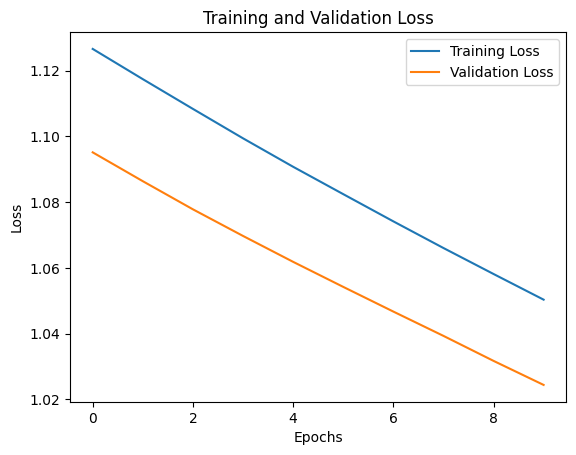

In [14]:
# plot loss vs val_loss
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

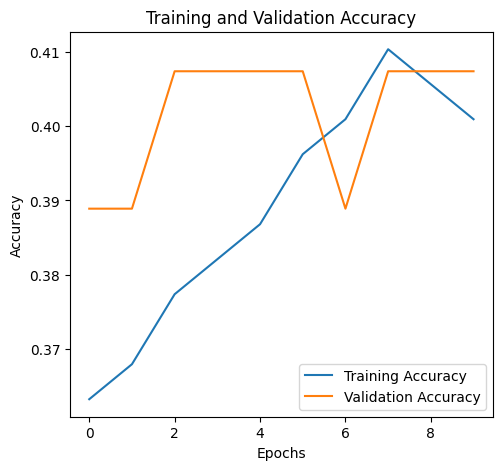

In [15]:
# plot the training and validation accuracy
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

### Model variability

Define, compile and train the model 3 times and see how your training and validation curves change. Are they the same or different? Why is this happening?

By defining, compiling and training the model 3 seperate times, each occurence changes the performance of the model. The first run did a decent job of fitting the model, however the second runthrough overfit and the 3rd underfit. This is happening because even with the same random set seed, the model starts with different weights and a validation split which can lead to different training data. These differences become more pronounced in small datasets. 

In [16]:
#constructing model 2.0
tf.random.set_seed(222)

inputs = keras.Input(shape=(6,))
x = layers.Dense(7, activation = 'relu')(inputs)
x = layers.Dense(5, activation = 'relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model")

In [17]:
### compiling 2.0
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history = model.fit(X_train_scaled, y_train,
                    batch_size = 128,
                    epochs=10,
                    validation_split=0.2,
                    verbose=1)

scores = model.evaluate(X_test_scaled, y_test, verbose = 1)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 300ms/step - accuracy: 0.0802 - loss: 1.2751 - val_accuracy: 0.0370 - val_loss: 1.3008
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.0896 - loss: 1.2659 - val_accuracy: 0.0370 - val_loss: 1.2904
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.0896 - loss: 1.2570 - val_accuracy: 0.0370 - val_loss: 1.2803
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.0896 - loss: 1.2483 - val_accuracy: 0.0370 - val_loss: 1.2705
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.1085 - loss: 1.2398 - val_accuracy: 0.0556 - val_loss: 1.2609
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.1274 - loss: 1.2316 - val_accuracy: 0.0741 - val_loss: 1.2516
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.1321 - loss: 1.2236 - val_accuracy: 0.0741 - val_loss: 1.2425
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.1321 - loss: 1.2159 - val_accuracy: 0.0741 - val_loss: 1.

In [18]:
### evaluating 2.0
y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print("\n Test Set Evaluation:")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

 Test Set Evaluation:
Test Accuracy: 0.1791
Test Precision: 0.1760
Test Recall: 0.1791
Test F1 Score: 0.1733
Test ROC AUC Score: 0.3535


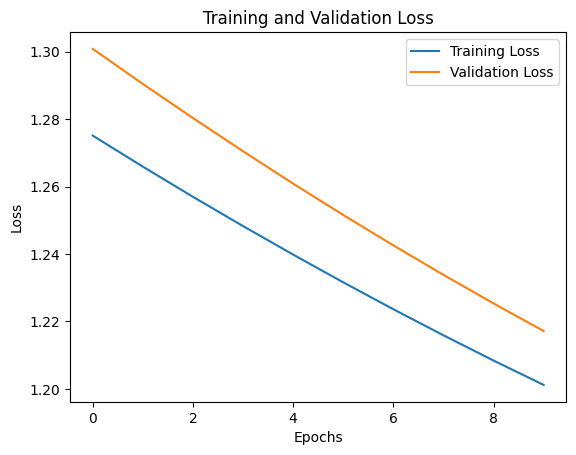

In [19]:
# plot loss vs val_loss 2.0
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

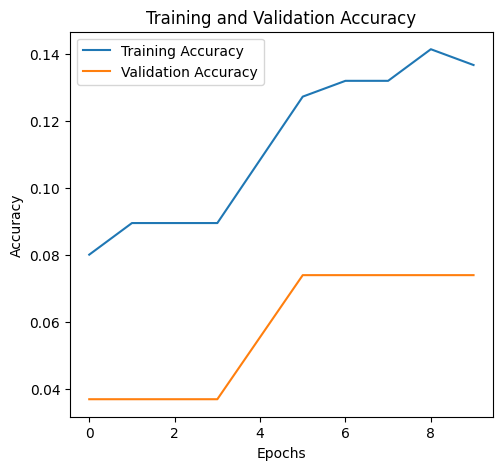

In [20]:
# plot the training and validation accuracy 2.0
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

In [21]:
#constructing model 3.0
tf.random.set_seed(222)

inputs = keras.Input(shape=(6,))
x = layers.Dense(7, activation = 'relu')(inputs)
x = layers.Dense(5, activation = 'relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model")

In [22]:
### compiling 3.0
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history = model.fit(X_train_scaled, y_train,
                    batch_size = 128,
                    epochs=10,
                    validation_split=0.2,
                    verbose=1)

scores = model.evaluate(X_test_scaled, y_test, verbose = 1)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 327ms/step - accuracy: 0.4057 - loss: 1.2838 - val_accuracy: 0.4259 - val_loss: 1.2659
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.4340 - loss: 1.2748 - val_accuracy: 0.4444 - val_loss: 1.2578
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.4292 - loss: 1.2660 - val_accuracy: 0.4444 - val_loss: 1.2498
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.4387 - loss: 1.2574 - val_accuracy: 0.4444 - val_loss: 1.2419
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.4387 - loss: 1.2488 - val_accuracy: 0.4630 - val_loss: 1.2342
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.4387 - loss: 1.2405 - val_accuracy: 0.3889 - val_loss: 1.2266
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.4151 - loss: 1.2322 - val_accuracy: 0.3889 - val_loss: 1.2191
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.4151 - loss: 1.2241 - val_accuracy: 0.4074 - val_loss: 1.2

In [23]:
### evaluating 3.0 
y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print("\n Test Set Evaluation:")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/stepWARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000018FD6AC2660> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

 Test Set Evaluation:
Test Accuracy: 0.4030
Test Precision: 0.1948
Test Recall: 0.4030
Test F1 Score: 0.2626
Test ROC AUC Score: 0.3500


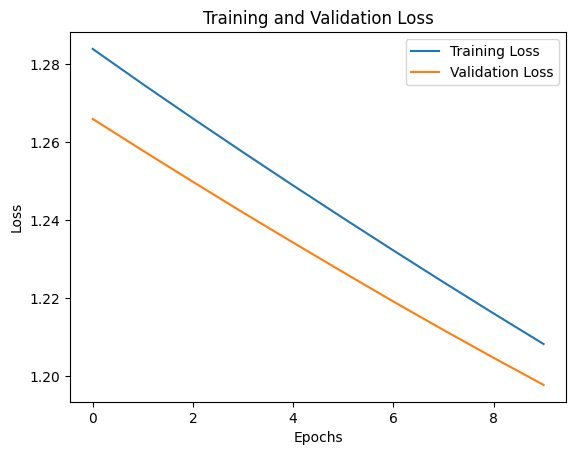

In [24]:
# plot loss vs val_loss 3.0
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

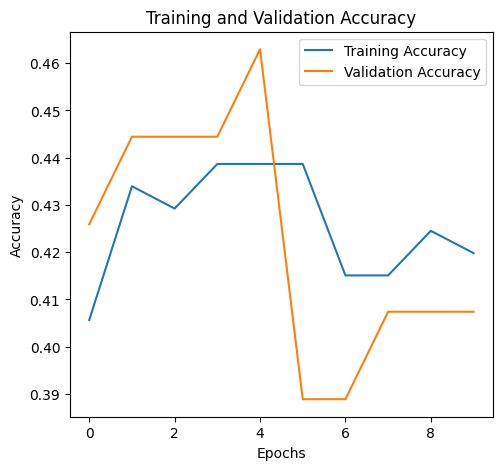

In [25]:
# plot the training and validation accuracy 3.0
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

### Setting a random seed

How does setting the tf random seed affect the training and validation curves?

Removing the random seed led to severe underfitting. This is because there is now more variability at the beggining of the process. When running this multiple times the variability in performance across each run increases. 


In [26]:
#constructing model w/out random seed
inputs = keras.Input(shape=(6,))
x = layers.Dense(7, activation = 'relu')(inputs)
x = layers.Dense(5, activation = 'relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model")

In [27]:
### compiling w/out random seed
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history = model.fit(X_train_scaled, y_train,
                    batch_size = 128,
                    epochs=10,
                    validation_split=0.2,
                    verbose=1)

scores = model.evaluate(X_test_scaled, y_test, verbose = 1)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 299ms/step - accuracy: 0.4387 - loss: 1.1207 - val_accuracy: 0.4444 - val_loss: 1.0752
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.4387 - loss: 1.1142 - val_accuracy: 0.4444 - val_loss: 1.0683
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.4387 - loss: 1.1079 - val_accuracy: 0.4444 - val_loss: 1.0616
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.4387 - loss: 1.1019 - val_accuracy: 0.4444 - val_loss: 1.0550
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.4387 - loss: 1.0959 - val_accuracy: 0.4444 - val_loss: 1.0486
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.4387 - loss: 1.0901 - val_accuracy: 0.4444 - val_loss: 1.0423
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.4387 - loss: 1.0846 - val_accuracy: 0.4444 - val_loss: 1.0364
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.4387 - loss: 1.0792 - val_accuracy: 0.4630 - val_loss: 1.0

In [28]:
### evaluating w/out random seed
y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print("\n Test Set Evaluation:")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

 Test Set Evaluation:
Test Accuracy: 0.4328
Test Precision: 0.1873
Test Recall: 0.4328
Test F1 Score: 0.2615
Test ROC AUC Score: 0.5416


c:\Users\Dirks Wright\OneDrive\Documents\Advanced Machine\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


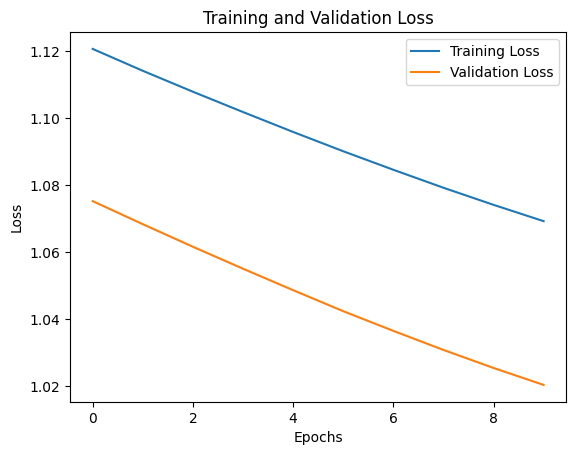

In [29]:
# plot loss vs val_loss w/out random seed
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

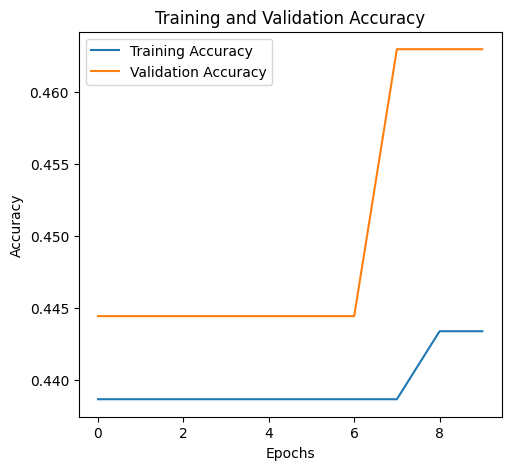

In [30]:
# plot the training and validation accuracy w/out random seed
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

### Modifying the hidden layers

Try three different configurations for the hidden layers. You are welcome to add or remove layers, to try different layer strategies (funnel, flat, etc ) and to vary the number of neurons. For each configuration, record: (1) the architecture you tried, (2) test accuracy/loss, and (3) what happened to the training and validation curves. What seemed to work best?

I tested three hidden-layer configurations: a small funnel model [7, 5], a flat model [8, 8], and a larger funnel model [16, 8, 4].

The best model was the flat model [8, 8] because it had the highest test accuracy (0.4328) along with the highest ROC-AUC score (0.7345), and lowest test loss (0.9672). The flat model seems to fit the data better than the other 2 models becuase it has a lower train acccuracy than validation accuracy.

The [7, 5] funnel model performed moderately well, with a test accuracy of 0.4179, ROC-AUC score of 0.5546, and test loss of 1.0603. Although its performance was close to the flat [8, 8] model in terms of accuracy, the much lower ROC-AUC score suggests that it was less effective at distinguishing between the different classes. The model likely overfit the data slightly because it had fewer neurons and the train data performed much better than the validation data. 

The [16, 8, 4] funnel model performed the worst overall, with the lowest test accuracy (0.3134), the lowest ROC-AUC score (0.5068), and the highest test loss (1.0805). This model was deeper and more complex and generalized well to the test data.As epochs increased both the training and validation accuracy increased. 



In [11]:
import matplotlib.pyplot as plt


config1_funnel_7_5


Model: "config1_funnel_7_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │            49 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107 (428.00 B)

 Trainable params: 107 (428.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 179ms/step - accuracy: 0.3868 - loss: 1.1750 - val_accuracy: 0.3333 - val_loss: 1.2750
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.4009 - loss: 1.1640 - val_accuracy: 0.3333 - val_loss: 1.2602
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.4009 - loss: 1.1532 - val_accuracy: 0.3333 - val_loss: 1.2459
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.4009 - loss: 1.1427 - val_accuracy: 0.3333 - val_loss: 1.2318
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.4009 - loss: 1.1323 - val_accuracy: 0.3333 - val_loss: 1.2180
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.4009 - loss: 1.1222 - val_accuracy: 0.3333 - val_loss: 1.2043
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.4009 - loss: 1.1123 - val_accuracy: 0.3333 - val_loss: 1.1910
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.4009 - loss: 1.1026 - val_accuracy: 0.3333 - val_loss: 1.1781

c:\Users\Dirks Wright\OneDrive\Documents\Advanced Machine\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


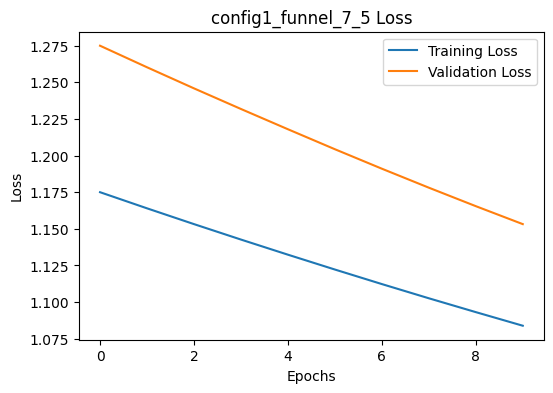

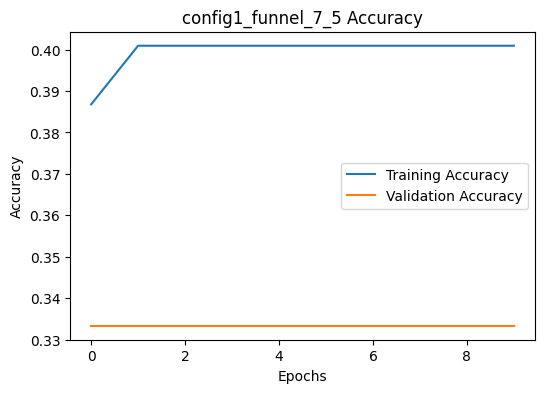


config2_flat_8_8


Model: "config2_flat_8_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 155 (620.00 B)

 Trainable params: 155 (620.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 463ms/step - accuracy: 0.4340 - loss: 1.0429 - val_accuracy: 0.4444 - val_loss: 1.0101
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.4340 - loss: 1.0348 - val_accuracy: 0.4444 - val_loss: 1.0020
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.4340 - loss: 1.0269 - val_accuracy: 0.4444 - val_loss: 0.9942
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.4340 - loss: 1.0192 - val_accuracy: 0.4444 - val_loss: 0.9867
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.4340 - loss: 1.0118 - val_accuracy: 0.4444 - val_loss: 0.9793
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.4340 - loss: 1.0045 - val_accuracy: 0.4444 - val_loss: 0.9720
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.4340 - loss: 0.9973 - val_accuracy: 0.4444 - val_loss: 0.9648
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.4387 - loss: 0.9903 - val_accuracy: 0.4444 - val_loss:

c:\Users\Dirks Wright\OneDrive\Documents\Advanced Machine\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


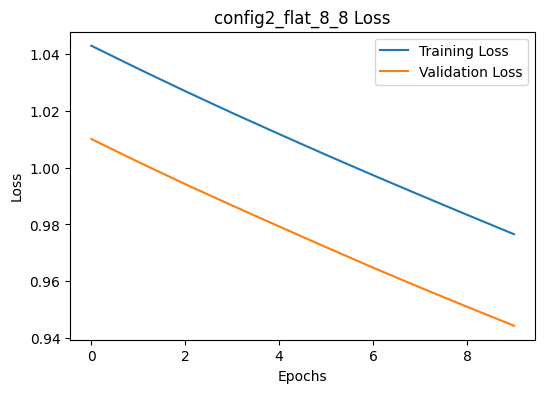

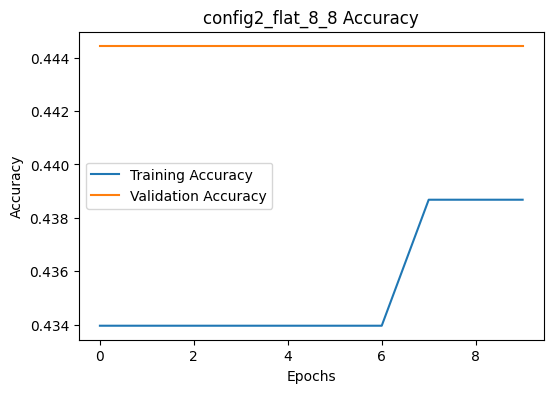


config3_funnel_16_8_4


Model: "config3_funnel_16_8_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 299 (1.17 KB)

 Trainable params: 299 (1.17 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 605ms/step - accuracy: 0.1321 - loss: 1.2104 - val_accuracy: 0.2222 - val_loss: 1.1457
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.1321 - loss: 1.1928 - val_accuracy: 0.2407 - val_loss: 1.1282
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.1462 - loss: 1.1761 - val_accuracy: 0.2407 - val_loss: 1.1120
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.1698 - loss: 1.1603 - val_accuracy: 0.2778 - val_loss: 1.0969
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.1887 - loss: 1.1452 - val_accuracy: 0.3148 - val_loss: 1.0827
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.2075 - loss: 1.1308 - val_accuracy: 0.3519 - val_loss: 1.0699
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.2500 - loss: 1.1168 - val_accuracy: 0.3889 - val_loss: 1.0577
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.2689 - loss: 1.1035 - val_accuracy: 0.3889 - val_loss:

c:\Users\Dirks Wright\OneDrive\Documents\Advanced Machine\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


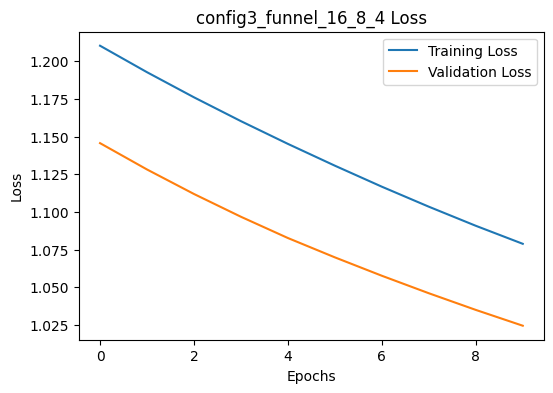

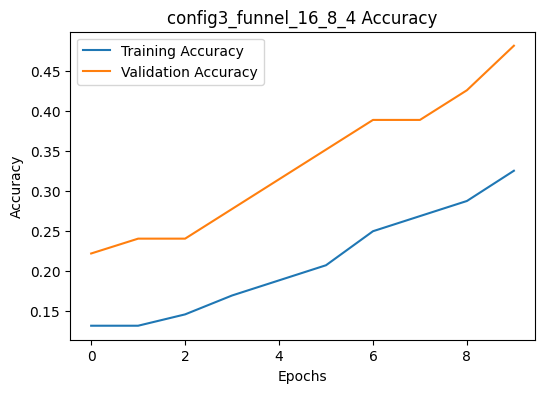

In [12]:
### 3 different configurations
configs = [
    {
        "name": "config1_funnel_7_5",
        "hidden_layers": [7, 5]
    },
    {
        "name": "config2_flat_8_8",
        "hidden_layers": [8, 8]
    },
    {
        "name": "config3_funnel_16_8_4",
        "hidden_layers": [16, 8, 4]
    }
]

### results list
results = []
### configuration loop
for config in configs:
    print("\n" + "="*60)
    print(config["name"])
    print("="*60)

    tf.keras.backend.clear_session()

    tf.random.set_seed(222)
    # Construct model
    inputs = keras.Input(shape=(6,))
    x = inputs

    for neurons in config["hidden_layers"]:
        x = layers.Dense(neurons, activation="relu")(x)

    outputs = layers.Dense(3, activation="softmax")(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name=config["name"]
    )

    # Compile model
    model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        optimizer=keras.optimizers.Adam(),
        metrics=["accuracy"]
    )

    model.summary()

    # Train model
    history = model.fit(
        X_train_scaled,
        y_train,
        batch_size=128,
        epochs=10,
        validation_split=0.2,
        verbose=1
    )

    # Evaluate model
    test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=1)

    y_pred_prob = model.predict(X_test_scaled)
    y_pred = np.argmax(y_pred_prob, axis=1)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")
    roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class="ovr")

    print("\nTest Set Evaluation:")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test Precision: {precision:.4f}")
    print(f"Test Recall: {recall:.4f}")
    print(f"Test F1 Score: {f1:.4f}")
    print(f"Test ROC AUC Score: {roc_auc:.4f}")

    results.append({
        "Architecture": config["hidden_layers"],
        "Test Loss": test_loss,
        "Test Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC AUC": roc_auc,
        "History": history
    })

    # Plot loss curves
    plt.figure(figsize=(6, 4))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title(config["name"] + " Loss")
    plt.legend()
    plt.show()

    # Plot accuracy curves
    plt.figure(figsize=(6, 4))
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title(config["name"] + " Accuracy")
    plt.legend()
    plt.show()

In [13]:
for r in results:
    print("\nArchitecture:", r["Architecture"])
    print(f"Test Loss: {r['Test Loss']:.4f}")
    print(f"Test Accuracy: {r['Test Accuracy']:.4f}")
    print(f"F1 Score: {r['F1']:.4f}")
    print(f"ROC AUC: {r['ROC AUC']:.4f}")


Architecture: [7, 5]
Test Loss: 1.0603
Test Accuracy: 0.4179
F1 Score: 0.3707
ROC AUC: 0.5546

Architecture: [8, 8]
Test Loss: 0.9672
Test Accuracy: 0.4328
F1 Score: 0.2699
ROC AUC: 0.7345

Architecture: [16, 8, 4]
Test Loss: 1.0805
Test Accuracy: 0.3134
F1 Score: 0.2747
ROC AUC: 0.5068


### Modifying the training cycles (epochs)

Vary the number of epochs. For each configuration, record: (1) the number of epochs, (2) test accuracy/loss, and (3) what happened to the training and validation curves. What was the minimum number of epochs needed for reliable model performance?



Training with 5 epochs
Epoch 1/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 0.4387 - loss: 1.2535 - val_accuracy: 0.4444 - val_loss: 1.2422
Epoch 2/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.4434 - loss: 1.2311 - val_accuracy: 0.4630 - val_loss: 1.2203
Epoch 3/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.4481 - loss: 1.2094 - val_accuracy: 0.4630 - val_loss: 1.1990
Epoch 4/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.4481 - loss: 1.1882 - val_accuracy: 0.4630 - val_loss: 1.1782
Epoch 5/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.4481 - loss: 1.1677 - val_accuracy: 0.4630 - val_loss: 1.1579
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4478 - loss: 1.1415 

Epochs: 5
Test Loss: 1.1415
Test Accuracy: 0.4478


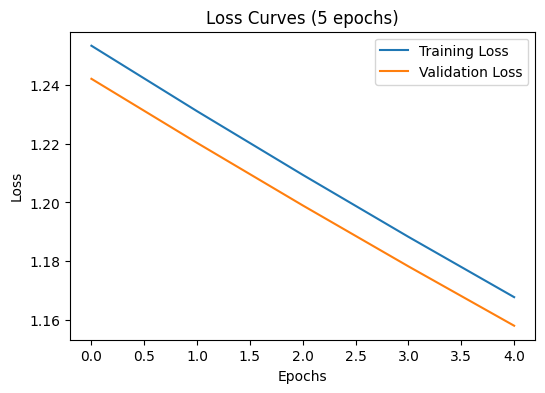

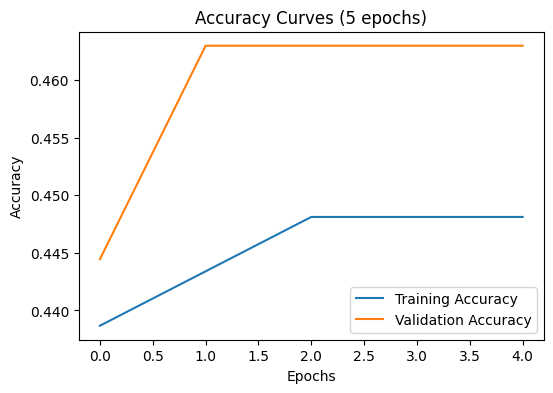


Training with 10 epochs
Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 196ms/step - accuracy: 0.4151 - loss: 1.5068 - val_accuracy: 0.3704 - val_loss: 1.5449
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3821 - loss: 1.4829 - val_accuracy: 0.3704 - val_loss: 1.5202
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3821 - loss: 1.4601 - val_accuracy: 0.3704 - val_loss: 1.4963
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.3821 - loss: 1.4381 - val_accuracy: 0.3704 - val_loss: 1.4733
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.3821 - loss: 1.4168 - val_accuracy: 0.3704 - val_loss: 1.4510
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.3821 - loss: 1.3963 - val_accuracy: 0.3704 - val_loss: 1.4295
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.3821 - loss: 1.3766 - val_accuracy: 0.3704 - val_loss: 1.4091
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3821 - loss: 1.3578 - val_accuracy: 

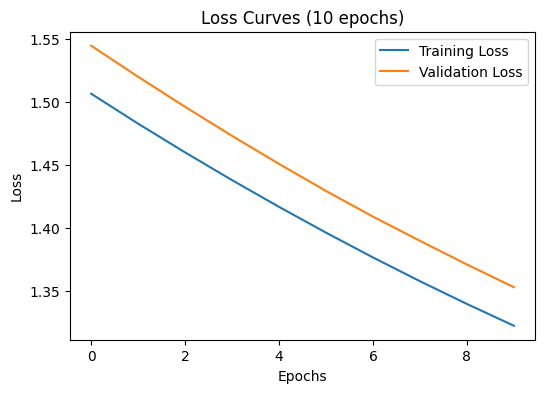

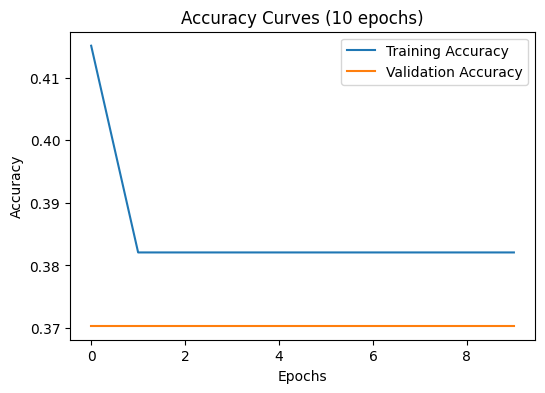


Training with 25 epochs
Epoch 1/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step - accuracy: 0.4340 - loss: 1.0448 - val_accuracy: 0.5370 - val_loss: 0.9618
Epoch 2/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.4670 - loss: 1.0324 - val_accuracy: 0.5741 - val_loss: 0.9484
Epoch 3/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.4670 - loss: 1.0201 - val_accuracy: 0.5741 - val_loss: 0.9352
Epoch 4/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.4906 - loss: 1.0079 - val_accuracy: 0.5926 - val_loss: 0.9223
Epoch 5/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5094 - loss: 0.9957 - val_accuracy: 0.6296 - val_loss: 0.9095
Epoch 6/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5330 - loss: 0.9837 - val_accuracy: 0.6481 - val_loss: 0.8968
Epoch 7/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5566 - loss: 0.9717 - val_accuracy: 0.6481 - val_loss: 0.8843
Epoch 8/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5660 - loss: 0.9600 - val_accuracy: 

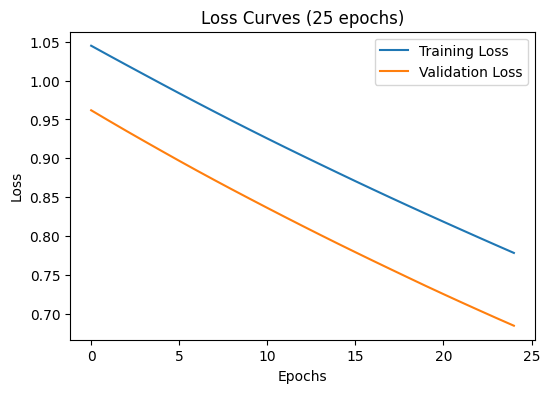

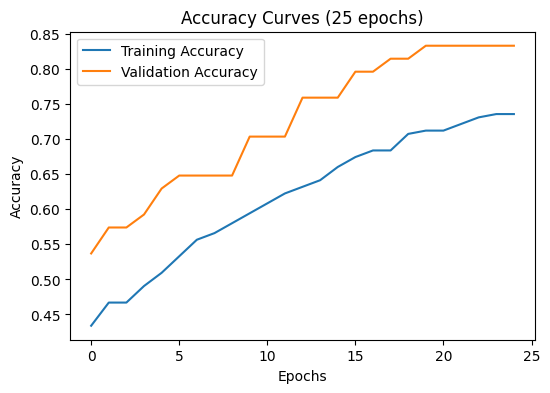

In [14]:
epoch_configs = [5, 10, 25]

results = []

for num_epochs in epoch_configs:

    print("\n" + "="*50)
    print(f"Training with {num_epochs} epochs")
    print("="*50)

    tf.keras.backend.clear_session()

    tf.random.set_seed(222)

    # Build SAME model each time
    inputs = keras.Input(shape=(6,))
    x = layers.Dense(8, activation='relu')(inputs)
    x = layers.Dense(8, activation='relu')(x)
    outputs = layers.Dense(3, activation='softmax')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    # Compile
    model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        optimizer=keras.optimizers.Adam(),
        metrics=['accuracy']
    )

    # Train
    history = model.fit(
        X_train_scaled,
        y_train,
        batch_size=128,
        epochs=num_epochs,
        validation_split=0.2,
        verbose=1
    )

    # Evaluate
    test_loss, test_accuracy = model.evaluate(
        X_test_scaled,
        y_test,
        verbose=1
    )

    print(f"\nEpochs: {num_epochs}")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

    results.append({
        "epochs": num_epochs,
        "loss": test_loss,
        "accuracy": test_accuracy
    })

    # Plot loss
    plt.figure(figsize=(6,4))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Loss Curves ({num_epochs} epochs)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # Plot accuracy
    plt.figure(figsize=(6,4))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'Accuracy Curves ({num_epochs} epochs)')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

In [15]:
for r in results:
    print("\n" + "="*40)
    print(f"Epochs: {r['epochs']}")
    print(f"Test Loss: {r['loss']:.4f}")
    print(f"Test Accuracy: {r['accuracy']:.4f}")


Epochs: 5
Test Loss: 1.1415
Test Accuracy: 0.4478

Epochs: 10
Test Loss: 1.3617
Test Accuracy: 0.3731

Epochs: 25
Test Loss: 0.7712
Test Accuracy: 0.7910



5 Epochs: Highest test loss and middle accuracy. As the epochs progressed, performance slighly improved for both the training and validation accuracy scores. However, performance waas poor the entire time. 

10 Epochs: Middle test loss and lowest accuracy. The validation accuracy was consistently poor, and the training accuracy did worse across epochs. 

25 Epochs: This model had the highest accuracy and loswest test loss. As te epochs progressed both the training and validation accuracy continued to increase, with the validation accuracy outperforming the training accuraccy. 

The minimum number of epochs for reliable performance is probably around 15 because this is where the validation accuracy reaches 0.75. 

### Early stopping, l2 regularization and dropout

In [16]:
# sample model

tf.random.set_seed(42)  # set seed for reproducibility

inputs = keras.Input(shape=(6,))  # 6 input features

x = layers.Dense(
    7,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 penalty on weights
)(inputs)
x = layers.Dropout(0.2)(x)  # randomly drop 20% of neurons during training

x = layers.Dense(
    5,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 applied again
)(x)
x = layers.Dropout(0.2)(x)  # dropout applied per layer

x = layers.Dense(
    3,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 on final hidden layer
)(x)
x = layers.Dropout(0.2)(x)  # dropout again (often not needed this deep)

outputs = layers.Dense(3, activation="softmax")(x)  # 3-class output → probabilities

model = keras.Model(inputs=inputs, outputs=outputs)  # build model (initialize weights)

model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),  # multiclass loss
    optimizer=keras.optimizers.Adam(),  # adaptive optimizer
    metrics=["accuracy"]  # track accuracy
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",  # watch validation loss
    patience=5,  # stop after 5 epochs without improvement
    restore_best_weights=True  # keep best-performing weights
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,  # maximum training length
    batch_size=64,
    validation_split=0.2,  # hold out 10% for validation
    callbacks=[early_stop],  # apply early stopping
    verbose=1
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.2358 - loss: 1.7159 - val_accuracy: 0.2778 - val_loss: 1.5032
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2877 - loss: 1.6225 - val_accuracy: 0.2778 - val_loss: 1.4738
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2925 - loss: 1.5847 - val_accuracy: 0.2778 - val_loss: 1.4457
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2877 - loss: 1.5914 - val_accuracy: 0.2778 - val_loss: 1.4189
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2830 - loss: 1.5763 - val_accuracy: 0.2778 - val_loss: 1.3927
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.2830 - loss: 1.5451 - val_accuracy: 0.2778 - val_loss: 1.3680
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2500 - loss: 1.3989 - val_accuracy: 0.2778 - val_loss: 1.3451
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2547 - loss: 1.4352 - val_accuracy: 0.2778 - val_loss:

In [17]:
# Evaluate model
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=1)

print("\nTest Set Evaluation:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

print(f"\nTraining stopped after {len(history.history['loss'])} epochs")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9254 - loss: 0.4888 

Test Set Evaluation:
Test Loss: 0.4888
Test Accuracy: 0.9254

Training stopped after 100 epochs


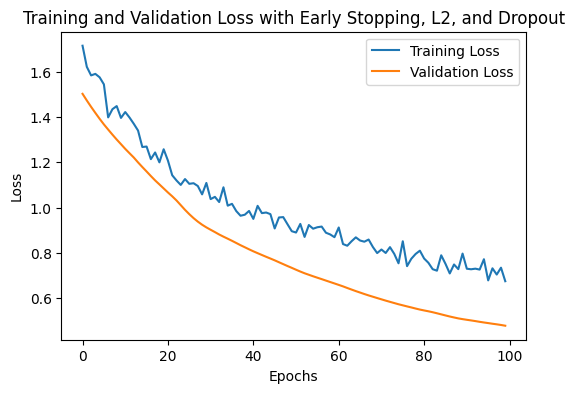

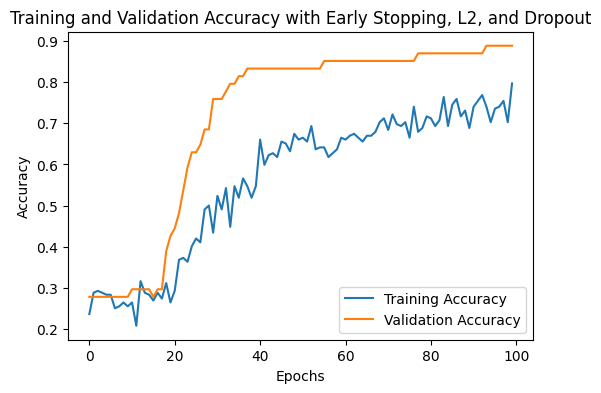

In [18]:
# Plot loss curves
plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss with Early Stopping, L2, and Dropout")
plt.legend()
plt.show()

# Plot accuracy curves
plt.figure(figsize=(6, 4))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy with Early Stopping, L2, and Dropout")
plt.legend()
plt.show()

### Tuning with Optuna

Adjust the code below to have the validation size, epochs and verbosity you found best from above. Then tune your model. You are welcome to increase the number of trials or to add parameters if you desire. Make sure the outputs of your cells are displayed. Then build a final model using your optimized parameters and predict on the test set.

In [34]:
! pip install plotly


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
! pip install optuna


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
import optuna
import plotly

In [37]:
# tuning the model with Optuna

def objective(trial):
    num_layers = trial.suggest_int("num_layers", 1, 3)  # number of hidden layers
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)  # log scale for LR
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])  # common batch sizes

    inputs = keras.Input(shape=(6,))  # 6 input features
    x = inputs

    for i in range(num_layers):
        units = trial.suggest_int(f"num_units_layer_{i+1}", 4, 32)  # neurons per layer
        x = layers.Dense(units, activation="relu")(x)  # hidden layer

    outputs = layers.Dense(3, activation="softmax")(x)  # 3 classes → softmax output
    model = keras.Model(inputs=inputs, outputs=outputs)  # build model

    model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),  # classification loss
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),  # optimizer with tuned LR
        metrics=["accuracy"],  # track accuracy
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",  # watch validation loss
        patience=5,  # stop after 5 epochs without improvement
        restore_best_weights=True  # keep best model weights
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        batch_size=batch_size,
        epochs=50,  # max training epochs
        validation_split=0.2,  # validation portion of training data
        verbose=0,  # suppress output during tuning
        callbacks=[early_stop]  # apply early stopping
    )

    return min(history.history["val_loss"])  # objective = best validation loss


study = optuna.create_study(direction="minimize")  # minimize validation loss
study.optimize(objective, n_trials=20)  # run 20 trials (20 models)

print("Best validation loss:", study.best_value)
print("Best parameters:", study.best_params)


[I 2026-05-14 15:52:09,259] A new study created in memory with name: no-name-5d5996eb-c592-4483-abd4-00b4aaf8bba6
[I 2026-05-14 15:52:14,699] Trial 0 finished with value: 0.22439712285995483 and parameters: {'num_layers': 2, 'learning_rate': 0.0002529461733754598, 'batch_size': 16, 'num_units_layer_1': 31, 'num_units_layer_2': 8}. Best is trial 0 with value: 0.22439712285995483.
[I 2026-05-14 15:52:19,566] Trial 1 finished with value: 0.029583649709820747 and parameters: {'num_layers': 1, 'learning_rate': 0.005245531367407576, 'batch_size': 16, 'num_units_layer_1': 16}. Best is trial 1 with value: 0.029583649709820747.
[I 2026-05-14 15:52:23,893] Trial 2 finished with value: 0.8381385207176208 and parameters: {'num_layers': 1, 'learning_rate': 0.0006129989718030052, 'batch_size': 64, 'num_units_layer_1': 11}. Best is trial 1 with value: 0.029583649709820747.
[I 2026-05-14 15:52:29,084] Trial 3 finished with value: 0.034694019705057144 and parameters: {'num_layers': 2, 'learning_rate': 

Best validation loss: 0.0035984280984848738
Best parameters: {'num_layers': 2, 'learning_rate': 0.009768066885377125, 'batch_size': 16, 'num_units_layer_1': 13, 'num_units_layer_2': 31}


In [44]:
%pip install plotly


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
import plotly

In [39]:
import optuna.visualization

C:\Users\Dirks Wright\AppData\Local\Temp\ipykernel_36056\942929590.py:6: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ovm.plot_optimization_history(study)


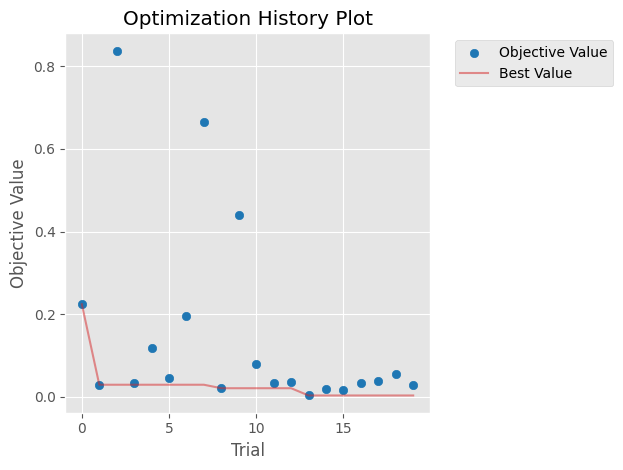

C:\Users\Dirks Wright\AppData\Local\Temp\ipykernel_36056\942929590.py:9: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ovm.plot_param_importances(study)


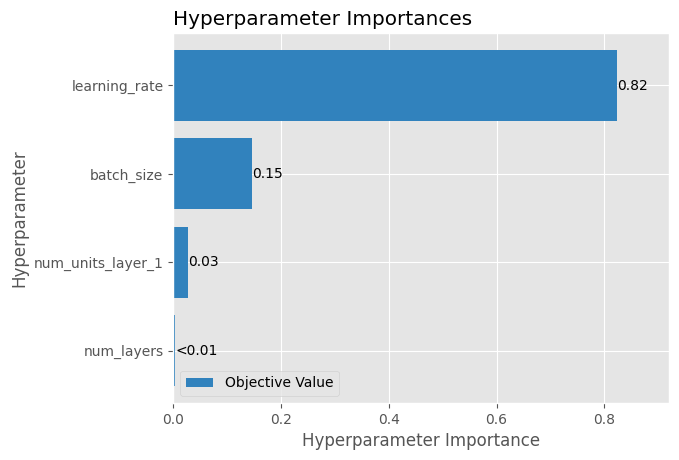

C:\Users\Dirks Wright\AppData\Local\Temp\ipykernel_36056\942929590.py:12: ExperimentalWarning: optuna.visualization.matplotlib._slice.plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  ovm.plot_slice(study)


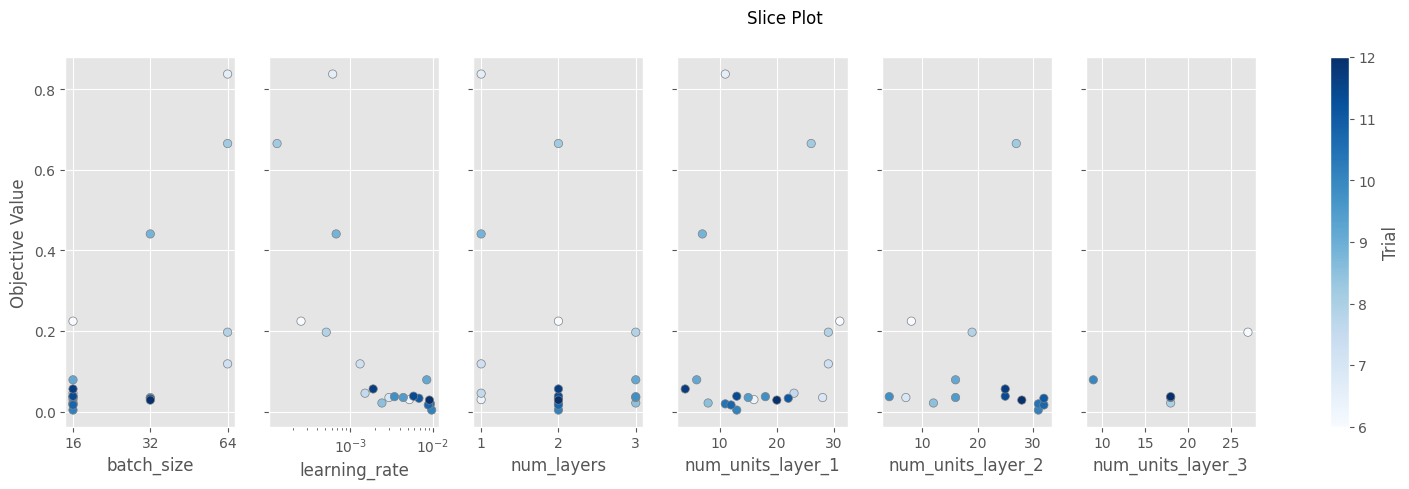

In [49]:
# visualizing Optuna results

import matplotlib.pyplot as plt
import optuna.visualization.matplotlib as ovm

ovm.plot_optimization_history(study)
plt.show()

ovm.plot_param_importances(study)
plt.show()

ovm.plot_slice(study)
plt.show()


In [48]:
# Building the best model from Optuna results
best_params = study.best_params
num_layers = best_params["num_layers"]
learning_rate = best_params["learning_rate"]
batch_size = best_params["batch_size"]
inputs = keras.Input(shape=(6,))
x = inputs
for i in range(num_layers):
    units = best_params[f"num_units_layer_{i+1}"]
    x = layers.Dense(units, activation="relu")(x)
outputs = layers.Dense(3, activation="softmax")(x)
best_model = keras.Model(inputs=inputs, outputs=outputs)
best_model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    metrics=["accuracy"],
)
history = best_model.fit(X_train_scaled, y_train, batch_size=batch_size, epochs=50, validation_split=0.2, verbose=1, callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)])
scores = best_model.evaluate(X_test_scaled, y_test, verbose=1)

# evaluate the best model using the test set
y_pred_prob = best_model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print("\n Best Model Test Set Evaluation:")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8538 - loss: 0.5479 - val_accuracy: 0.8889 - val_loss: 0.3133
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9434 - loss: 0.2365 - val_accuracy: 0.9259 - val_loss: 0.1396
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9953 - loss: 0.0705 - val_accuracy: 0.9815 - val_loss: 0.0469
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0201 - val_accuracy: 0.9815 - val_loss: 0.0304
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0104 - val_accuracy: 0.9815 - val_loss: 0.0282
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0077 - val_accuracy: 0.9815 - val_loss: 0.0281
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0063 - val_accuracy: 0.9815 - val_loss: 0.0276
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0053 - val_accuracy: 0.9815 - val_loss